In [124]:
import pandas as pd
import pulp as pl


archetype_df = pd.read_excel("../data/building_stock_archetypes.xlsx", index_col=0)


In [125]:
archetype_df.columns

Index(['Total Net floor Area',
       'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)', 'Geometry',
       'm²NGF', 'Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)',
       'Building Period', 'Bauperiode (Ebene +2)', 'Building Quality',
       'renovated', 'thermisch wirksame Speichermasse',
       ...
       'WW-Wärmebedarf__kWh/m²NGFa',
       'WW Endenergiebedarf Thermisch__kWh/m²NGFa',
       'WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa',
       'WW Hilfsstrom__', 'WW 1 Endenergie thermisch__kWh/m²NGFa',
       'WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa',
       'WW 1 Hilfsstrom__kWh/m²NGFa', 'WW 2 Endenergie thermisch__kWh/m²NGFa',
       'WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa',
       'WW 2 Hilfsstrom__kWh/m²NGFa'],
      dtype='object', length=519)

<Axes: xlabel='ID'>

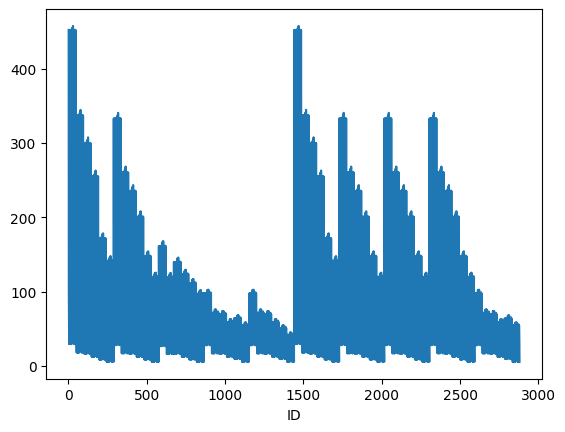

In [126]:
archetype_df["Heiwärmebedarf_Quartier_kWh/m²NGFa"].plot()

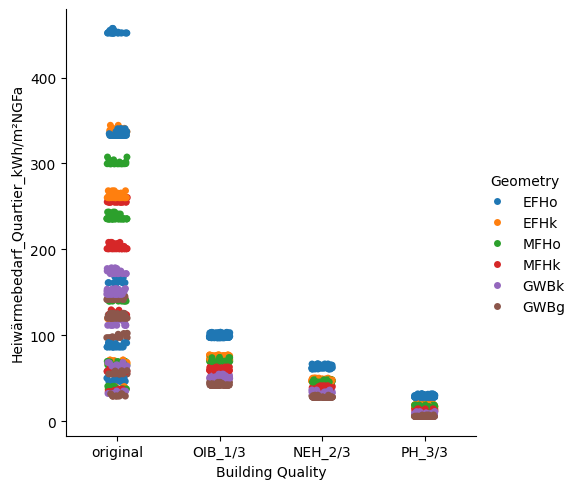

In [127]:
import seaborn as sns
sns.catplot(archetype_df, y="Heiwärmebedarf_Quartier_kWh/m²NGFa", x="Building Quality", hue="Geometry")

In [128]:
archetype_df["Heiwärmebedarf_Quartier_kWh/m²NGFa"]

ID
1       451.940557
2        98.588579
3        63.497412
4        29.502686
5       451.940557
           ...    
2876      7.050776
2877     54.880023
2878     41.997297
2879     27.969681
2880      5.587241
Name: Heiwärmebedarf_Quartier_kWh/m²NGFa, Length: 2880, dtype: float64

In [129]:
archetype_df.iloc[2]["Building Quality"]

'NEH_2/3'

In [130]:
archetype_df.Name

ID
1                  EFHo | bis 1944 - existing - Erdgas___
2       EFHo | bis 1944 - existing - Erdgas_WD1 nach O...
3       EFHo | bis 1944 - existing - Erdgas_WD2 NEH (2...
4       EFHo | bis 1944 - existing - Erdgas_WD3 PH (3/...
5         EFHo | bis 1944 - existing - Erdgas__Fernwärme_
                              ...                        
2876    GWBg | 2000 - 2020 - existing - Erdgas_WD3 PH ...
2877      GWBg | 2000 - 2020 - existing - Erdgas__Heizöl_
2878    GWBg | 2000 - 2020 - existing - Erdgas_WD1 nac...
2879    GWBg | 2000 - 2020 - existing - Erdgas_WD2 NEH...
2880    GWBg | 2000 - 2020 - existing - Erdgas_WD3 PH ...
Name: Name, Length: 2880, dtype: object

In [131]:

archetypes = archetype_df.Name.tolist()
archetypes[:10]

['EFHo | bis 1944 - existing - Erdgas___',
 'EFHo | bis 1944 - existing - Erdgas_WD1 nach OIB (1/3)__',
 'EFHo | bis 1944 - existing - Erdgas_WD2 NEH (2/3)__',
 'EFHo | bis 1944 - existing - Erdgas_WD3 PH (3/3, 30 cm)__',
 'EFHo | bis 1944 - existing - Erdgas__Fernwärme_',
 'EFHo | bis 1944 - existing - Erdgas_WD1 nach OIB (1/3)_Fernwärme_',
 'EFHo | bis 1944 - existing - Erdgas_WD2 NEH (2/3)_Fernwärme_',
 'EFHo | bis 1944 - existing - Erdgas_WD3 PH (3/3, 30 cm)_Fernwärme_',
 'EFHo | bis 1944 - existing - Erdgas__WP ineffizient_',
 'EFHo | bis 1944 - existing - Erdgas_WD1 nach OIB (1/3)_WP ineffizient_']

In [132]:
def setup_problem(archetype_df):
    prob = pl.LpProblem("ArchetypeNFA", pl.LpMinimize)
    var_dict = pl.LpVariable.dict("NFA", archetype_df.index.to_list(), lowBound=0, cat="Integer")
    return prob, var_dict

prob, var_dict = setup_problem(archetype_df)
var_dict

{1: NFA_1,
 2: NFA_2,
 3: NFA_3,
 4: NFA_4,
 5: NFA_5,
 6: NFA_6,
 7: NFA_7,
 8: NFA_8,
 9: NFA_9,
 10: NFA_10,
 11: NFA_11,
 12: NFA_12,
 13: NFA_13,
 14: NFA_14,
 15: NFA_15,
 16: NFA_16,
 17: NFA_17,
 18: NFA_18,
 19: NFA_19,
 20: NFA_20,
 21: NFA_21,
 22: NFA_22,
 23: NFA_23,
 24: NFA_24,
 25: NFA_25,
 26: NFA_26,
 27: NFA_27,
 28: NFA_28,
 29: NFA_29,
 30: NFA_30,
 31: NFA_31,
 32: NFA_32,
 33: NFA_33,
 34: NFA_34,
 35: NFA_35,
 36: NFA_36,
 37: NFA_37,
 38: NFA_38,
 39: NFA_39,
 40: NFA_40,
 41: NFA_41,
 42: NFA_42,
 43: NFA_43,
 44: NFA_44,
 45: NFA_45,
 46: NFA_46,
 47: NFA_47,
 48: NFA_48,
 49: NFA_49,
 50: NFA_50,
 51: NFA_51,
 52: NFA_52,
 53: NFA_53,
 54: NFA_54,
 55: NFA_55,
 56: NFA_56,
 57: NFA_57,
 58: NFA_58,
 59: NFA_59,
 60: NFA_60,
 61: NFA_61,
 62: NFA_62,
 63: NFA_63,
 64: NFA_64,
 65: NFA_65,
 66: NFA_66,
 67: NFA_67,
 68: NFA_68,
 69: NFA_69,
 70: NFA_70,
 71: NFA_71,
 72: NFA_72,
 73: NFA_73,
 74: NFA_74,
 75: NFA_75,
 76: NFA_76,
 77: NFA_77,
 78: NFA_78,
 79:

In [133]:
type(var_dict[1])

pulp.pulp.LpVariable

In [134]:
NFA_constraints = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="NGF" )
NFA_constraints


,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Bauperiode (Ebene +2),target_column,target_value
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,Vor 1919,NaN,983229
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1919 bis 1944,NaN,391933
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1945 bis 1960,NaN,594234
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1961 bis 1970,NaN,629490
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1971 bis 1980,NaN,634503
...,...,...,...,...,...,...,...
895,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1971 bis 1980,NaN,5451357
896,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1981 bis 1990,NaN,3794303
897,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,1991 bis 2000,NaN,3135980
898,2021,Wien,Wohngebäude,1 000 Quadratmeter und mehr,2001 bis 2010,NaN,4900876


In [135]:
NFA_constraints = NFA_constraints[
    NFA_constraints["Region – Gebietsstand 2023 (Ebene +2)"] == "Zusammen"
]
NFA_constraints

,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Bauperiode (Ebene +2),target_column,target_value
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,Vor 1919,NaN,983229
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1919 bis 1944,NaN,391933
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1945 bis 1960,NaN,594234
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1961 bis 1970,NaN,629490
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1971 bis 1980,NaN,634503
...,...,...,...,...,...,...,...
85,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,1971 bis 1980,NaN,16136574
86,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,1981 bis 1990,NaN,9391856
87,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,1991 bis 2000,NaN,7838404
88,2021,Zusammen,Wohngebäude,1 000 Quadratmeter und mehr,2001 bis 2010,NaN,12858774


In [136]:

for c in NFA_constraints.itertuples():
    geb_eig = c[3]
    size_class = c[4]
    age_class = c[5]
    nfa_target = c[7]
    print(c)

Pandas(Index=0, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _5='Vor 1919', target_column=nan, target_value=983229)
Pandas(Index=1, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _5='1919 bis 1944', target_column=nan, target_value=391933)
Pandas(Index=2, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _5='1945 bis 1960', target_column=nan, target_value=594234)
Pandas(Index=3, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _5='1961 bis 1970', target_column=nan, target_value=629490)
Pandas(Index=4, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _5='1971 bis 1980', target_column=nan, target_value=634503)
Pandas(Index=5, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _5='1981 bis 1990', target_column=nan, target_value=653133)
Pandas(Index=6, Jahr=2021, _2='Zusammen', _3='Andere Gebäude', _4='Unter 200 Quadratmeter', _

In [137]:
selection = archetype_df[
    (archetype_df["Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)"] == "Wohngebäude")&
    (archetype_df["Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)"] == "Unter 200 Quadratmeter")&
    (archetype_df["Bauperiode (Ebene +2)"] == "1945 bis 1960")
]
selection.Name

ID
289            EFHo | 1945 - 1989 - existing - Erdgas___
290    EFHo | 1945 - 1989 - existing - Erdgas_WD1 nac...
291    EFHo | 1945 - 1989 - existing - Erdgas_WD2 NEH...
292    EFHo | 1945 - 1989 - existing - Erdgas_WD3 PH ...
293    EFHo | 1945 - 1989 - existing - Erdgas__Fernwä...
                             ...                        
380    EFHk | 1945 - 1989 - existing - Erdgas_WD3 PH ...
381      EFHk | 1945 - 1989 - existing - Erdgas__Heizöl_
382    EFHk | 1945 - 1989 - existing - Erdgas_WD1 nac...
383    EFHk | 1945 - 1989 - existing - Erdgas_WD2 NEH...
384    EFHk | 1945 - 1989 - existing - Erdgas_WD3 PH ...
Name: Name, Length: 96, dtype: object

In [138]:
def apply_NFA_constraints(constraints_df, archetype_df, pl_problem, pl_var_dict):
    
    for c in constraints_df.itertuples():
        geb_eig = c[3]
        size_class = c[4]
        age_class = c[5]
        nfa_target = c[7]
        selection = archetype_df[
            (archetype_df["Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)"] == geb_eig)&
            (archetype_df["Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)"] == size_class)&
            (archetype_df["Bauperiode (Ebene +2)"] == age_class)
        ]
        print(geb_eig, size_class, age_class, nfa_target, selection.index)
        if len(selection) > 0:
            pl_problem += (
                pl.lpSum(pl_var_dict[i+1]  for i in selection.index) == nfa_target
            )


In [139]:
prob, var_dict = setup_problem(archetype_df)
apply_NFA_constraints(NFA_constraints, archetype_df, prob, var_dict)
prob

Andere Gebäude Unter 200 Quadratmeter Vor 1919 983229 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 1919 bis 1944 391933 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 1945 bis 1960 594234 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 1961 bis 1970 629490 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 1971 bis 1980 634503 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 1981 bis 1990 653133 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 1991 bis 2000 573485 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 2001 bis 2010 603461 Index([], dtype='int64', name='ID')
Andere Gebäude Unter 200 Quadratmeter 2011 und später 610016 Index([], dtype='int64', name='ID')
Andere Gebäude 200 bis unter 300 Quadratmeter Vor 1919 1223343 Index([], dtype='int64', name='ID')
Andere Gebäude 200 bis unter 300 Quadratmeter 191

ArchetypeNFA:
MINIMIZE
None
SUBJECT TO
_C1: NFA_10 + NFA_11 + NFA_12 + NFA_13 + NFA_14 + NFA_15 + NFA_16 + NFA_17
 + NFA_18 + NFA_19 + NFA_2 + NFA_20 + NFA_21 + NFA_22 + NFA_23 + NFA_24
 + NFA_25 + NFA_26 + NFA_27 + NFA_28 + NFA_29 + NFA_3 + NFA_30 + NFA_31
 + NFA_32 + NFA_33 + NFA_34 + NFA_35 + NFA_36 + NFA_37 + NFA_38 + NFA_39
 + NFA_4 + NFA_40 + NFA_41 + NFA_42 + NFA_43 + NFA_44 + NFA_45 + NFA_46
 + NFA_47 + NFA_48 + NFA_49 + NFA_5 + NFA_50 + NFA_51 + NFA_52 + NFA_53
 + NFA_54 + NFA_55 + NFA_56 + NFA_57 + NFA_58 + NFA_59 + NFA_6 + NFA_60
 + NFA_61 + NFA_62 + NFA_63 + NFA_64 + NFA_65 + NFA_66 + NFA_67 + NFA_68
 + NFA_69 + NFA_7 + NFA_70 + NFA_71 + NFA_72 + NFA_73 + NFA_74 + NFA_75
 + NFA_76 + NFA_77 + NFA_78 + NFA_79 + NFA_8 + NFA_80 + NFA_81 + NFA_82
 + NFA_83 + NFA_84 + NFA_85 + NFA_86 + NFA_87 + NFA_88 + NFA_89 + NFA_9
 + NFA_90 + NFA_91 + NFA_92 + NFA_93 + NFA_94 + NFA_95 + NFA_96 + NFA_97
 = 18855939

_C2: NFA_1442 + NFA_1443 + NFA_1444 + NFA_1445 + NFA_1446 + NFA_1447
 + NFA_14

In [140]:
prob.solve()


1

<Axes: xlabel='ID'>

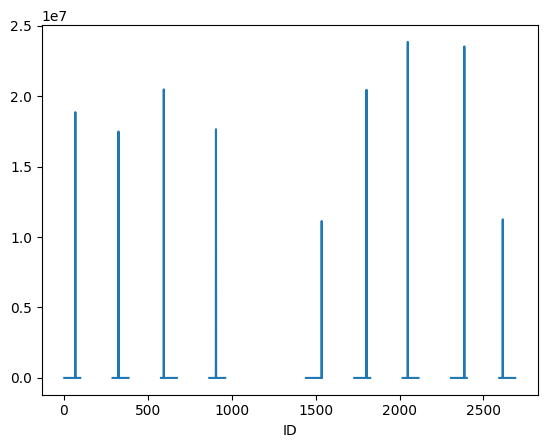

In [141]:
result = archetype_df.copy()
result["NFA"] = pd.Series({i: var_dict[i].value() for i in archetype_df.index})
result.NFA.plot()

<Axes: ylabel='Name'>

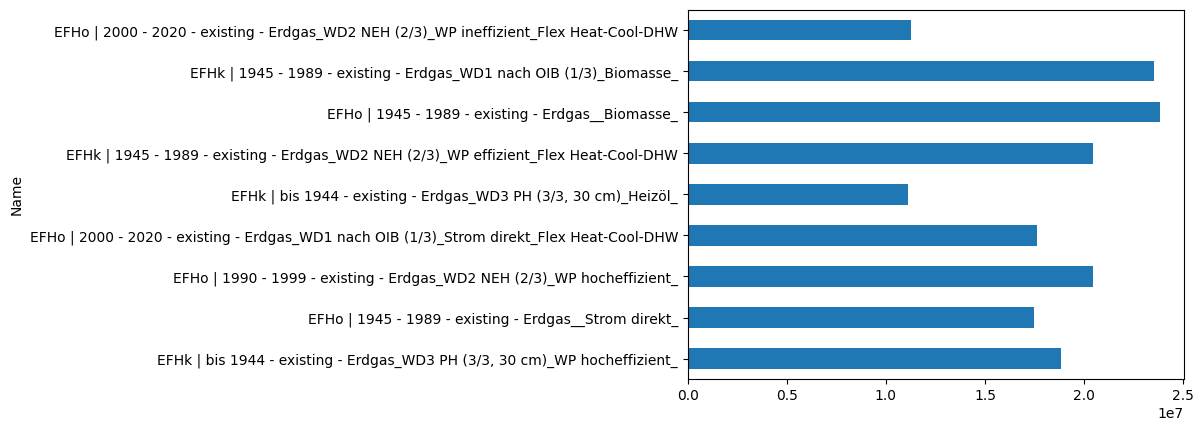

In [142]:
result = archetype_df.copy()
result["NFA"] = pd.Series({i: var_dict[i].value() for i in archetype_df.index})

plot_df = result.loc[result["NFA"] > 0, ["Name", "NFA"]].set_index("Name")
plot_df["NFA"].plot(kind="barh")

In [143]:
def apply_NFA_constraints(constraints_df, archetype_df, pl_problem, pl_var_dict):
    
    for c in constraints_df.itertuples():
        geb_eig = c[3]
        size_class = c[4]
        age_class = c[5]
        nfa_target = c[7]
        selection = archetype_df[
            (archetype_df["Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)"] == geb_eig)&
            (archetype_df["Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)"] == size_class)&
            (archetype_df["Bauperiode (Ebene +2)"] == age_class)
        ]
        print(geb_eig, size_class, age_class, nfa_target, selection.index)
        if len(selection) > 0:
            pl_problem += (
                pl.lpSum(pl_var_dict[i+1] for i in selection.index) == nfa_target
            )


In [144]:

objective_terms = []

In [145]:
%load_ext autoreload
%autoreload 2
from archifer.model import BuildingSector

bs = BuildingSector(archetype_df=archetype_df)
bs.archetypes.head()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,...,WW-Wärmebedarf__kWh/m²NGFa,WW Endenergiebedarf Thermisch__kWh/m²NGFa,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa
ID,,,,,,,,,,,,,,,,,,,,,
1,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,15.975,15.97561,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0
2,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,OIB_1/3,1,mittel (124 Wh/m²K),...,15.975,15.97561,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0
3,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,NEH_2/3,1,mittel (124 Wh/m²K),...,15.975,15.97561,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0
4,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,PH_3/3,1,mittel (124 Wh/m²K),...,15.975,15.97561,0.79878,0.79878,15.97561,0.79878,0.79878,0,0,0
5,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),...,15.975,17.75061,0.88753,0.88753,17.75061,0.88753,0.88753,0,0,0


In [146]:
NFA_constraints = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="NGF" )
NFA_constraints = NFA_constraints[
    NFA_constraints["Region – Gebietsstand 2023 (Ebene +2)"] == "Zusammen"
]
filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)",
    "Bauperiode (Ebene +2)"
]

NFA_constraints.head()

,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Bauperiode (Ebene +2),target_column,target_value
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,Vor 1919,NaN,983229
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1919 bis 1944,NaN,391933
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1945 bis 1960,NaN,594234
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1961 bis 1970,NaN,629490
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1971 bis 1980,NaN,634503


In [147]:
bs.add_constraints_from_df(constraints_df=NFA_constraints,
                           filter_cols=filter_cols,
                           target = "target_value",
                           weight=1_000_000,
                           name_prefix="Stat_AT_NFA"
                        )
                        

Skipping Stat_AT_NFA_0: no matching archetypes
Skipping Stat_AT_NFA_1: no matching archetypes
Skipping Stat_AT_NFA_2: no matching archetypes
Skipping Stat_AT_NFA_3: no matching archetypes
Skipping Stat_AT_NFA_4: no matching archetypes
Skipping Stat_AT_NFA_5: no matching archetypes
Skipping Stat_AT_NFA_6: no matching archetypes
Skipping Stat_AT_NFA_7: no matching archetypes
Skipping Stat_AT_NFA_8: no matching archetypes
Skipping Stat_AT_NFA_9: no matching archetypes
Skipping Stat_AT_NFA_10: no matching archetypes
Skipping Stat_AT_NFA_11: no matching archetypes
Skipping Stat_AT_NFA_12: no matching archetypes
Skipping Stat_AT_NFA_13: no matching archetypes
Skipping Stat_AT_NFA_14: no matching archetypes
Skipping Stat_AT_NFA_15: no matching archetypes
Skipping Stat_AT_NFA_16: no matching archetypes
Skipping Stat_AT_NFA_17: no matching archetypes
Skipping Stat_AT_NFA_18: no matching archetypes
Skipping Stat_AT_NFA_19: no matching archetypes
Skipping Stat_AT_NFA_20: no matching archetypes
Sk

<Axes: title={'center': 'Optimization result'}, xlabel='NFA'>

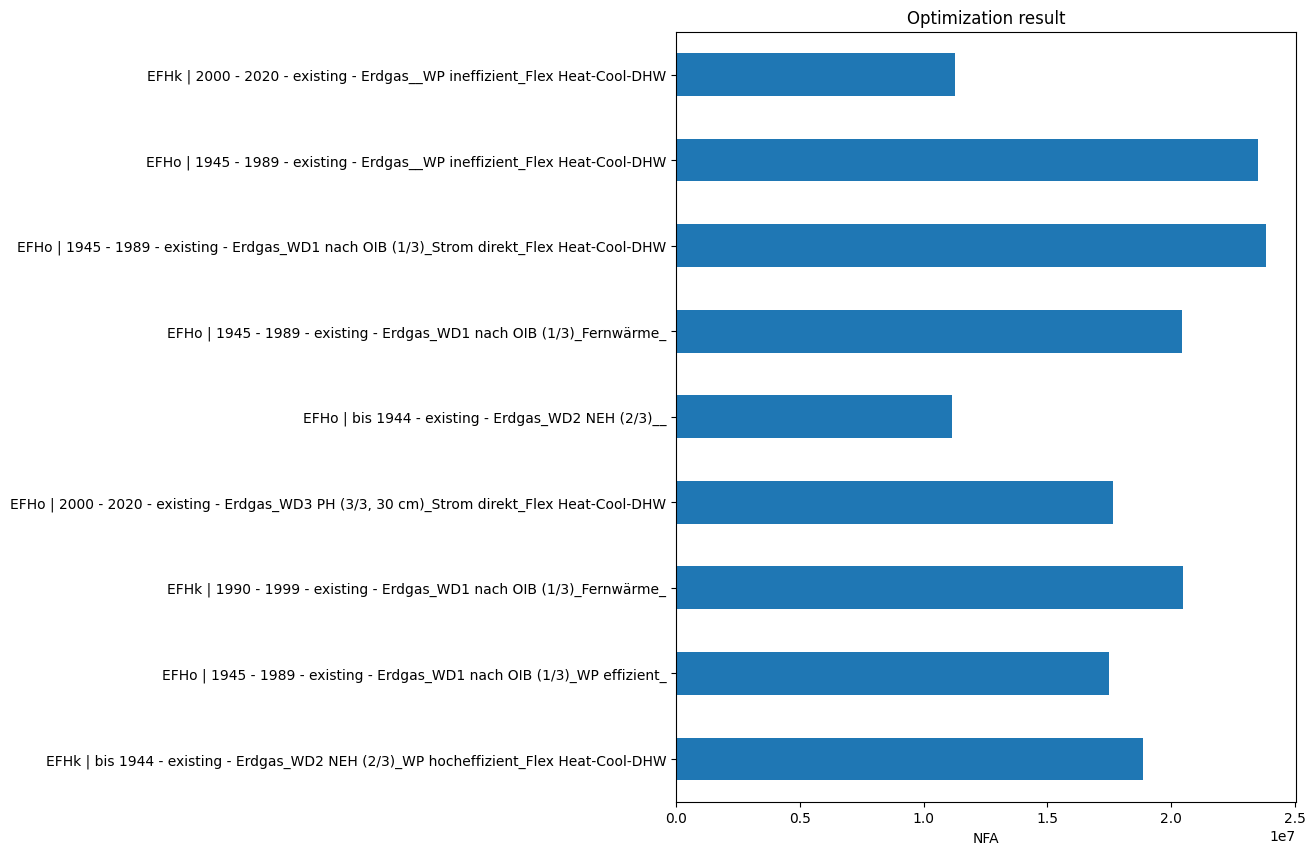

In [148]:
bs.solve()
bs.plot_result()

In [149]:
ee_constraints = pd.read_excel("../data/constraints_sector_model.xlsx", sheet_name="EE")
ee_constraints

,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Energy Supply,target_column,target_value
0,2021,Zusammen,Wohngebäude,NaN,Gas_Quartier_kWh/m²NGFa,1.703739e+10
1,2021,Zusammen,Wohngebäude,NaN,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10
2,2021,Zusammen,Wohngebäude,NaN,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09
3,2021,Zusammen,Wohngebäude,NaN,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10
4,2021,Zusammen,Wohngebäude,Electricity,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09
5,2021,Zusammen,Wohngebäude,Heat Pump,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09
6,2021,Zusammen,Wohngebäude,NaN,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10
7,2021,Zusammen,Wohngebäude,NaN,Heizen_Endenergiebedarf_kWh/m²NGFa,5.198375e+10


In [150]:


ee_filters = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Energy Supply",
]
bs.add_constraints_from_df(constraints_df=ee_constraints,
                           filter_cols=ee_filters,
                           target = "target_value",
                           weight=1_000,
                           name_prefix="EndEnergy"
                        )


Skipping Stat_AT_NFA_0: no matching archetypes
Skipping Stat_AT_NFA_1: no matching archetypes
Skipping Stat_AT_NFA_2: no matching archetypes
Skipping Stat_AT_NFA_3: no matching archetypes
Skipping Stat_AT_NFA_4: no matching archetypes
Skipping Stat_AT_NFA_5: no matching archetypes
Skipping Stat_AT_NFA_6: no matching archetypes
Skipping Stat_AT_NFA_7: no matching archetypes
Skipping Stat_AT_NFA_8: no matching archetypes
Skipping Stat_AT_NFA_9: no matching archetypes
Skipping Stat_AT_NFA_10: no matching archetypes
Skipping Stat_AT_NFA_11: no matching archetypes
Skipping Stat_AT_NFA_12: no matching archetypes
Skipping Stat_AT_NFA_13: no matching archetypes
Skipping Stat_AT_NFA_14: no matching archetypes
Skipping Stat_AT_NFA_15: no matching archetypes
Skipping Stat_AT_NFA_16: no matching archetypes
Skipping Stat_AT_NFA_17: no matching archetypes
Skipping Stat_AT_NFA_18: no matching archetypes
Skipping Stat_AT_NFA_19: no matching archetypes
Skipping Stat_AT_NFA_20: no matching archetypes
Sk

<Axes: title={'center': 'Optimization result'}, xlabel='NFA'>

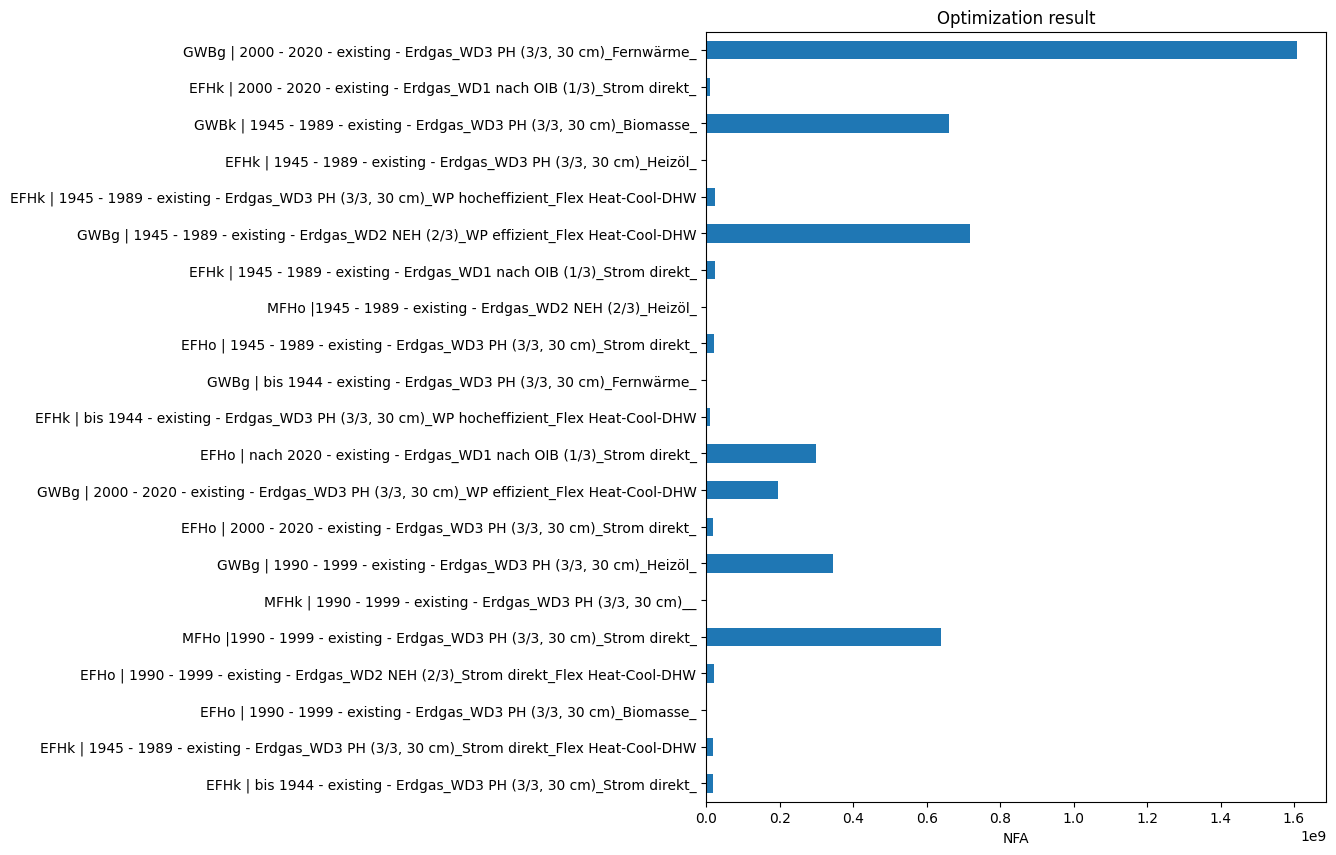

In [151]:
bs.solve()
bs.plot_result()

In [152]:
bs.list_constraints()

,name,type,filter,column,target,weight
0,Stat_AT_NFA_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,9.832290e+05,1000000
1,Stat_AT_NFA_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,3.919330e+05,1000000
2,Stat_AT_NFA_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,5.942340e+05,1000000
3,Stat_AT_NFA_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,6.294900e+05,1000000
4,Stat_AT_NFA_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,None,6.345030e+05,1000000
...,...,...,...,...,...,...
93,EndEnergy_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1000
94,EndEnergy_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1000
95,EndEnergy_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1000
96,EndEnergy_6,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10,1000


In [153]:
bs.remove_constraints("Stat")
bs.list_constraints()


,name,type,filter,column,target,weight
0,EndEnergy_0,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Gas_Quartier_kWh/m²NGFa,1.703739e+10,1000
1,EndEnergy_1,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Biomasse_Quartier_kWh/m²NGFa,1.972013e+10,1000
2,EndEnergy_2,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Fernwärme_Quartier_kWh/m²NGFa,9.715264e+09,1000
3,EndEnergy_3,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Sonstige_Quartier_kWh/m²NGFa,1.085499e+10,1000
4,EndEnergy_4,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,3.566548e+09,1000
5,EndEnergy_5,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Netzstrom_Heizen_kWh/m²NGFa,2.204916e+09,1000
6,EndEnergy_6,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Warmwasser_Endenergiebedarf_kWh/m²NGFa,1.073889e+10,1000
7,EndEnergy_7,absolute,{'Gebäudeigenschaft (überwiegende Nutzung) (Eb...,Heizen_Endenergiebedarf_kWh/m²NGFa,5.198375e+10,1000


Skipping EndEnergy_4: no matching archetypes
Status: Optimal


<Axes: title={'center': 'Optimization result'}, xlabel='NFA'>

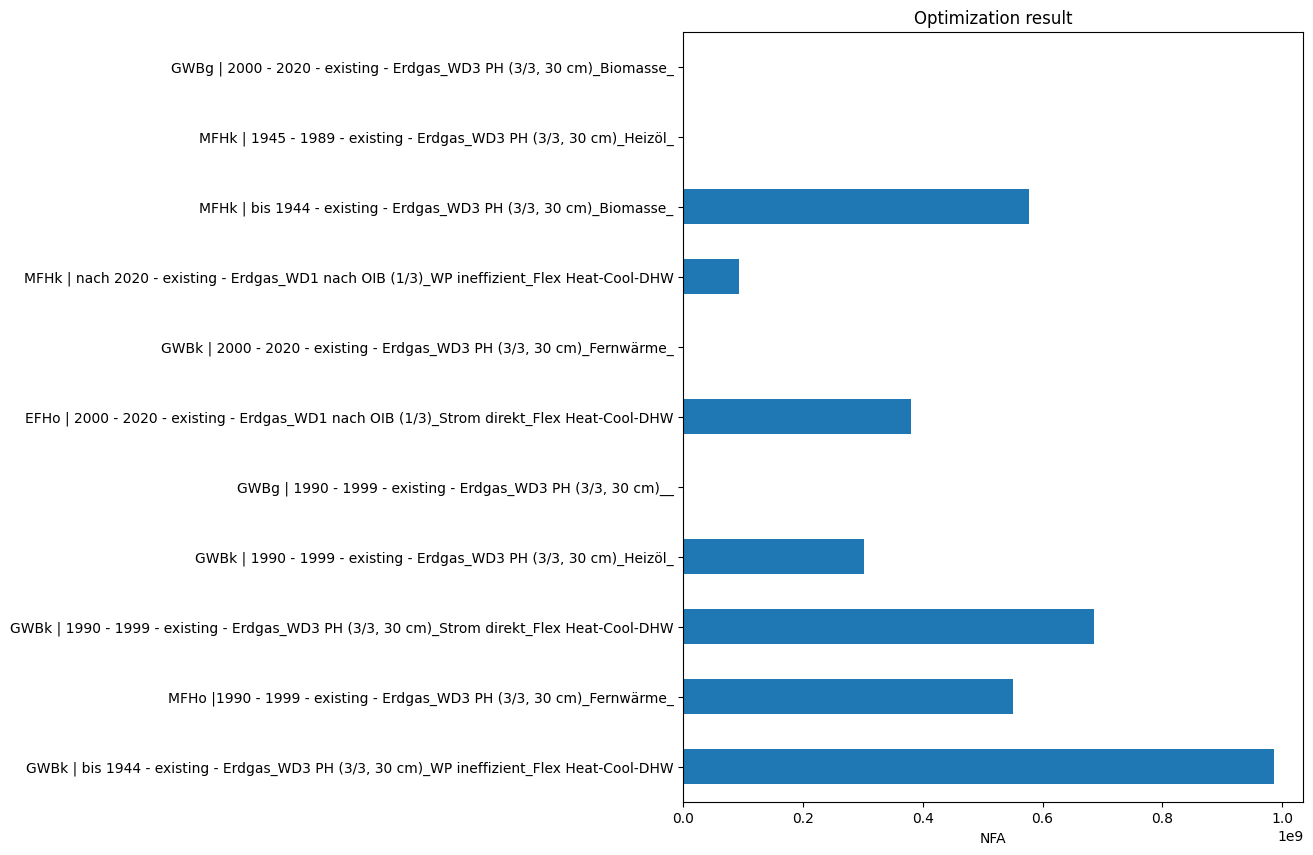

In [154]:

bs.solve()
bs.plot_result()

In [155]:
%autoreload 2
from archifer.model import Constraint
bs.add_constraint(
    Constraint(
        name="share_gas",
        filter={"Energy Supply": "Natural Gas"},   # numerator
        column=None,                      # sum NFA_i
        target=0.30,                      # 30%
        weight=1_000_000,
        type="share",
        reference_filter=None,            # denominator: all archetypes
        
    )
)

TypeError: Constraint.__init__() got an unexpected keyword argument 'type'